# 03.2 Compare Regime Feature as an Input
## Experiment Design
This notebook compares four boosting classifiers (XGBoost, LightGBM, CatBoost,
HistGradientBoosting) on the task of forecasting FOMC meeting decisions.

**Two feature sets are compared side-by-side:**
- **Base** (22 features): macroeconomic lags from `df_model.csv`
- **+ Regime** (23 features): base + a single `regime_enc` feature derived from
  the policy regime identified in `03.1_state_identification.ipynb`

**Regime encoding:**
| `regime_simple` | `regime_enc` |
|---|---|
| Tightening | **+1** |
| Plateau | **0** |
| Easing | **-1** |

**No look-ahead guarantee:** For an FOMC meeting on date `d`, the regime feature
is taken from the daily regime series on date `d-1` — i.e., what was observable
*before* the meeting outcome was known.

**Both** feature sets are tuned with Optuna (same search spaces, same n_trials)
and evaluated under identical expanding-window walk-forward validation.

> In the tuning and results sections below, each model family appears twice by
> design: once for the **base** feature set and once for the **+ regime** feature set.


In [1]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import HistGradientBoostingClassifier

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.catboost_artifacts import (
    catboost_artifact_available,
    load_03_2_artifact,
)
from modeling.notebook_io import resolve_data_source

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed — skipping')

CATBOOST_AVAILABLE = catboost_artifact_available(PROJECT_ROOT, '03_2_compare_regime.json')
catboost_bundle_03_2 = load_03_2_artifact(PROJECT_ROOT) if CATBOOST_AVAILABLE else None
if not CATBOOST_AVAILABLE:
    print('CatBoost artifacts not found — run: python scripts/build_catboost_artifacts.py')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna not installed — HPO disabled')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print('Imports OK')
print(f'  XGBoost  : {XGBOOST_AVAILABLE}')
print(f'  LightGBM : {LGBM_AVAILABLE}')
print(f'  CatBoost : {CATBOOST_AVAILABLE}')
print(f'  Optuna   : {OPTUNA_AVAILABLE}')


Imports OK
  XGBoost  : True
  LightGBM : True
  CatBoost : True
  Optuna   : True


In [2]:
# ── Data sources ─────────────────────────────────────────────────────────────
_FEDRATE_URL = resolve_data_source('fedrate_all.csv', PROJECT_ROOT)
_MODEL_URL   = resolve_data_source('df_model.csv', PROJECT_ROOT)

# ── Target label encoding ──────────────────────────────────────────────────────
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}   # original → encoded (0/1/2)
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}   # encoded → original (-1/0/1)
CLASS_NAMES   = {-1: 'Lower', 0: 'Same', 1: 'Higher'}
ENCODED_NAMES = { 0: 'Lower', 1: 'Same', 2: 'Higher'}
LABEL_VALS    = [-1, 0, 1]

# ── Walk-forward configuration ─────────────────────────────────────────────────
INITIAL_TRAIN_SIZE = 40   # first 40 meetings used for warm-up training
TUNE_START         = 55   # Optuna evaluates on meetings 55 → end (≈ 80 predictions)

# ── Regime encoding (user specification) ──────────────────────────────────────
REGIME_ENC = {'Tightening': 1, 'Plateau': 0, 'Easing': -1}

# ── Regime identification parameters (match 03.1_state_identification.ipynb) ───
W_MEET    = 6     # rolling window (FOMC decisions)
THETA     = 0.15  # drift threshold
M         = 1     # persistence filter
FOMC_DAYS = 42    # synthetic hold cadence (days)
ALPHA_REG = 1.0   # Dirichlet smoothing

# ── Optuna trial budgets ───────────────────────────────────────────────────────
N_TRIALS = {'xgb': 30, 'lgbm': 30, 'cat': 25, 'hgb': 15}

print('Constants set.')


Constants set.


In [3]:
# ── Regime labeling functions (from 03.1_state_identification.ipynb) ──────────

def label_policy_regime(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1, tol=1e-9,
    mode="realtime", alpha=1.0,
):
    """Label each row with a 3-state policy regime + Dirichlet probability vector."""
    assert mode in ("realtime", "analysis")

    df_out = df.copy()
    if date_col in df_out.columns:
        df_out = df_out.sort_values(date_col).reset_index(drop=True)

    rate = df_out[rate_col].copy()
    if rate.isna().sum() > 0:
        rate = rate.ffill()
    n = len(rate)

    delta_r  = rate.diff()
    decision = pd.Series("Hold", index=rate.index, dtype=object)
    decision[delta_r >  tol] = "Hike"
    decision[delta_r < -tol] = "Cut"
    decision[delta_r.isna()] = None

    is_hike = (decision == "Hike").fillna(False).astype(float)
    is_cut  = (decision == "Cut" ).fillna(False).astype(float)
    H_t = is_hike.rolling(W, min_periods=1).sum()
    C_t = is_cut .rolling(W, min_periods=1).sum()
    D_t = (H_t - C_t) / W

    n_events     = pd.Series(range(1, n + 1), index=rate.index, dtype=float).clip(upper=W)
    N_t          = (n_events - H_t - C_t).clip(lower=0)
    denom        = n_events + 3.0 * alpha
    p_tightening = (H_t + alpha) / denom
    p_easing     = (C_t + alpha) / denom
    p_plateau    = (N_t + alpha) / denom

    last_dir    = [None] * n
    current_dir = None
    for i in range(n):
        d = decision.iloc[i]
        if d == "Hike":
            current_dir = "Hike"
        elif d == "Cut":
            current_dir = "Cut"
        last_dir[i] = current_dir

    if mode == "analysis":
        rate_vals    = rate.values.astype(float)
        is_local_max = np.zeros(n, dtype=bool)
        is_local_min = np.zeros(n, dtype=bool)
        for i in range(n):
            lo, hi = max(0, i - k), min(n - 1, i + k)
            window = rate_vals[lo : hi + 1]
            if rate_vals[i] == window.max():
                is_local_max[i] = True
            if rate_vals[i] == window.min():
                is_local_min[i] = True
        most_recent_lmax = np.full(n, np.nan)
        most_recent_lmin = np.full(n, np.nan)
        last_lmax_val = np.nan
        last_lmin_val = np.nan
        for i in range(n):
            if is_local_max[i]: last_lmax_val = rate_vals[i]
            if is_local_min[i]: last_lmin_val = rate_vals[i]
            most_recent_lmax[i] = last_lmax_val
            most_recent_lmin[i] = last_lmin_val

    raw_regime = []
    for i in range(n):
        dt = D_t.iloc[i]
        if dt >= theta:
            raw_regime.append("Tightening")
        elif dt <= -theta:
            raw_regime.append("Easing")
        else:
            if mode == "realtime":
                ld = last_dir[i]
                if   ld == "Hike": raw_regime.append("Hold-High")
                elif ld == "Cut":  raw_regime.append("Hold-Low")
                else:              raw_regime.append("Neutral Hold / Transition")
            else:
                rv   = rate_vals[i]
                lmax = most_recent_lmax[i]
                lmin = most_recent_lmin[i]
                near_max = is_local_max[i] or (not np.isnan(lmax) and rv >= lmax - epsilon_bps)
                near_min = is_local_min[i] or (not np.isnan(lmin) and rv <= lmin + epsilon_bps)
                if   near_max and not near_min: raw_regime.append("Hold-High")
                elif near_min and not near_max: raw_regime.append("Hold-Low")
                elif near_max and near_min:
                    ld = last_dir[i]
                    if   ld == "Hike": raw_regime.append("Hold-High")
                    elif ld == "Cut":  raw_regime.append("Hold-Low")
                    else:              raw_regime.append("Neutral Hold / Transition")
                else:
                    raw_regime.append("Neutral Hold / Transition")

    final_regime   = [None] * n
    current_regime = raw_regime[0]
    candidate      = None
    cand_count     = 0
    for i in range(n):
        r = raw_regime[i]
        if r == current_regime:
            candidate  = None
            cand_count = 0
        else:
            if r == candidate:
                cand_count += 1
            else:
                candidate  = r
                cand_count = 1
            if cand_count >= m:
                current_regime = candidate
                candidate      = None
                cand_count     = 0
        final_regime[i] = current_regime

    final_s       = pd.Series(final_regime, index=rate.index)
    regime_change = final_s != final_s.shift(1)
    regime_change.iloc[0] = False

    PLATEAU_STATES = {"Hold-High", "Hold-Low", "Neutral Hold / Transition"}

    df_out["delta_r"]       = delta_r.values
    df_out["decision"]      = decision.values
    df_out["H_t"]           = H_t.values
    df_out["C_t"]           = C_t.values
    df_out["N_t"]           = N_t.values
    df_out["D_t"]           = D_t.values
    df_out["raw_regime"]    = raw_regime
    df_out["regime"]        = final_regime
    df_out["regime_change"] = regime_change.values
    df_out["regime_simple"] = [("Plateau" if r in PLATEAU_STATES else r) for r in final_regime]
    df_out["p_tightening"]  = p_tightening.values
    df_out["p_easing"]      = p_easing.values
    df_out["p_plateau"]     = p_plateau.values
    return df_out


def label_policy_regime_daily(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1, tol=1e-9,
    mode="realtime", fomc_cycle_days=42, alpha=1.0,
):
    """Wrapper for daily data: inserts synthetic Holds, labels, forward-fills."""
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    rate        = df[rate_col].ffill()
    delta_r_abs = rate.diff().abs()

    seg_starts = [0] + list(df.index[delta_r_abs > tol].tolist())
    event_idx_set = set()
    for pos, seg_start in enumerate(seg_starts):
        event_idx_set.add(seg_start)
        seg_end        = seg_starts[pos + 1] if (pos + 1 < len(seg_starts)) else len(df)
        seg_start_date = df[date_col].iloc[seg_start]
        seg_len_days   = int((df[date_col].iloc[seg_end - 1] - seg_start_date).days)
        for day_off in range(fomc_cycle_days, seg_len_days, fomc_cycle_days):
            target_date = seg_start_date + pd.Timedelta(days=day_off)
            seg_slice   = df.iloc[seg_start : seg_end]
            nearest_idx = (seg_slice[date_col] - target_date).abs().idxmin()
            event_idx_set.add(nearest_idx)

    event_idx_sorted = sorted(event_idx_set)
    df_events = df.iloc[event_idx_sorted].copy().reset_index(drop=True)
    print(f"  Daily rows   : {len(df):,}")
    print(f"  Event rows   : {len(df_events):,}  (rate-changes + synthetic holds every {fomc_cycle_days}d)")

    df_ev_lab = label_policy_regime(
        df_events,
        rate_col=rate_col, date_col=date_col,
        W=W, theta=theta, k=k, epsilon_bps=epsilon_bps,
        m=m, tol=tol, mode=mode, alpha=alpha,
    )

    label_cols = ["delta_r", "decision", "H_t", "C_t", "N_t", "D_t",
                  "raw_regime", "regime", "regime_simple",
                  "p_tightening", "p_easing", "p_plateau"]

    df_daily = df.merge(df_ev_lab[[date_col] + label_cols], on=date_col, how="left")
    for col in label_cols:
        df_daily[col] = df_daily[col].ffill()

    regime_s = df_daily["regime_simple"].fillna("Plateau")
    df_daily["regime_change"] = regime_s != regime_s.shift(1)
    df_daily.loc[0, "regime_change"] = False
    return df_daily


print("label_policy_regime() and label_policy_regime_daily() defined.")


label_policy_regime() and label_policy_regime_daily() defined.


In [4]:
# ── 1. Load raw data ──────────────────────────────────────────────────────────
df_fed   = pd.read_csv(_FEDRATE_URL, parse_dates=['observation_date'])
df_model = pd.read_csv(_MODEL_URL,   parse_dates=['meeting_date'])
df_fed   = df_fed.sort_values('observation_date').reset_index(drop=True)

print(f"df_fed   : {len(df_fed):,} rows  "
      f"({df_fed['observation_date'].min().date()} → "
      f"{df_fed['observation_date'].max().date()})")
print(f"df_model : {len(df_model)} rows  "
      f"({df_model['meeting_date'].min().date()} → "
      f"{df_model['meeting_date'].max().date()})")

# ── 2. Compute realtime regime on full daily history ───────────────────────────
print("\n── Computing realtime regime on fedrate_all.csv …")
df_rt = label_policy_regime_daily(
    df_fed, rate_col="fed_rate", date_col="observation_date",
    W=W_MEET, theta=THETA, m=M,
    fomc_cycle_days=FOMC_DAYS, alpha=ALPHA_REG, mode="realtime",
)

# fedrate_all_with_regime: the full daily dataframe with regime columns
fedrate_all_with_regime = df_rt.copy()
print(f"\nfedrate_all_with_regime: {len(fedrate_all_with_regime):,} rows, "
      f"{len(fedrate_all_with_regime.columns)} columns")
print("Columns added:", [c for c in fedrate_all_with_regime.columns
                         if c not in ['observation_date', 'fed_rate']])
print("\nRegime distribution (daily):")
print(fedrate_all_with_regime['regime_simple'].value_counts().to_string())

# ── 3. Merge regime into df_model (no look-ahead) ─────────────────────────────
# For meeting on date d, use regime on date d-1 (the last observable day before
# the meeting outcome is known).
print("\n── Merging regime into df_model …")

_lookup = (
    fedrate_all_with_regime[['observation_date', 'regime_simple',
                              'p_tightening', 'p_easing', 'p_plateau']]
    .copy()
    .sort_values('observation_date')
    .reset_index(drop=True)
)

df_regime = df_model.copy().sort_values('meeting_date').reset_index(drop=True)

# For each meeting, find the regime on the closest date BEFORE the meeting
meeting_dates  = pd.to_datetime(df_regime['meeting_date'])
lookup_dates   = pd.to_datetime(_lookup['observation_date'])

regime_vals    = []
p_tight_vals   = []
p_ease_vals    = []
p_plat_vals    = []

for mdate in meeting_dates:
    cutoff = mdate - pd.Timedelta(days=1)           # day before meeting
    mask   = lookup_dates <= cutoff
    if mask.any():
        row = _lookup.loc[mask.index[mask][-1]]     # last row ≤ cutoff
    else:
        row = _lookup.iloc[0]                        # fallback: earliest row
    regime_vals.append(row['regime_simple'])
    p_tight_vals.append(row['p_tightening'])
    p_ease_vals.append(row['p_easing'])
    p_plat_vals.append(row['p_plateau'])

df_regime['regime_simple']  = regime_vals
df_regime['regime_enc']     = [REGIME_ENC[r] for r in regime_vals]
df_regime['p_tightening']   = p_tight_vals
df_regime['p_easing']       = p_ease_vals
df_regime['p_plateau']      = p_plat_vals

print("\nMeeting-level regime distribution:")
print(df_regime['regime_simple'].value_counts().to_string())
print("\nSample (meeting_date, regime, regime_enc):")
print(df_regime[['meeting_date', 'decision', 'regime_simple', 'regime_enc']].to_string())


df_fed   : 14,668 rows  (1986-01-01 → 2026-02-27)
df_model : 136 rows  (2009-08-12 → 2026-01-28)

── Computing realtime regime on fedrate_all.csv …
  Daily rows   : 14,668
  Event rows   : 412  (rate-changes + synthetic holds every 42d)

fedrate_all_with_regime: 14,668 rows, 15 columns
Columns added: ['delta_r', 'decision', 'H_t', 'C_t', 'N_t', 'D_t', 'raw_regime', 'regime', 'regime_simple', 'p_tightening', 'p_easing', 'p_plateau', 'regime_change']

Regime distribution (daily):
regime_simple
Easing        5048
Tightening    5046
Plateau       4574

── Merging regime into df_model …

Meeting-level regime distribution:
regime_simple
Plateau       70
Tightening    42
Easing        24

Sample (meeting_date, regime, regime_enc):
    meeting_date decision regime_simple  regime_enc
0     2009-08-12     same        Easing          -1
1     2009-09-23     same       Plateau           0
2     2009-11-04     same       Plateau           0
3     2009-12-16     same       Plateau           0
4     

In [5]:
# ── Feature / target arrays ────────────────────────────────────────────────────
NON_FEAT_COLS = ['meeting_date', 'decision', 'decision_num', 'prev_decision',
                 'regime_simple', 'p_tightening', 'p_easing', 'p_plateau']

# Base features (22): original macroeconomic lags
feature_cols_base = [c for c in df_model.columns if c not in NON_FEAT_COLS]

# Regime features (23): base + regime_enc
feature_cols_regime = feature_cols_base + ['regime_enc']

# Build arrays
y_orig = df_regime['decision_num'].values.astype(int)
y_enc  = np.array([LABEL_MAP[v] for v in y_orig])

X_base   = df_regime[feature_cols_base  ].values.astype(float)
X_regime = df_regime[feature_cols_regime].values.astype(float)

meeting_dates = df_regime['meeting_date'].values

print(f"Target  y_enc : {y_enc.shape}  classes={np.unique(y_enc)}")
print(f"X_base        : {X_base.shape}  ({len(feature_cols_base)} features)")
print(f"X_regime      : {X_regime.shape}  ({len(feature_cols_regime)} features)")
print(f"  New feature   : 'regime_enc'  values={sorted(df_regime['regime_enc'].unique())}")
print(f"\nClass distribution in y_enc:")
for enc, name in ENCODED_NAMES.items():
    cnt = (y_enc == enc).sum()
    print(f"  {enc} ({name:6s}) : {cnt:3d}  ({100*cnt/len(y_enc):.1f}%)")


Target  y_enc : (136,)  classes=[0 1 2]
X_base        : (136, 28)  (28 features)
X_regime      : (136, 29)  (29 features)
  New feature   : 'regime_enc'  values=[-1, 0, 1]

Class distribution in y_enc:
  0 (Lower ) :  11  (8.1%)
  1 (Same  ) : 105  (77.2%)
  2 (Higher) :  20  (14.7%)


In [6]:
# ── Walk-forward helpers (same as 03_boosting_models_trained_on_economic_variables.ipynb) ──────────────────────

def augment_missing_classes(X_train, y_train, all_classes=(0, 1, 2)):
    """Inject one tiny synthetic sample per missing class so classifiers see all 3."""
    present  = set(y_train)
    missing  = set(all_classes) - present
    counts   = np.bincount(y_train, minlength=3)
    n_total  = len(y_train)
    real_w   = np.array([n_total / (3 * max(counts[c], 1)) for c in y_train], dtype=float)
    if not missing:
        return X_train, y_train, real_w
    X_mean  = X_train.mean(axis=0, keepdims=True)
    X_synth = np.vstack([X_mean] * len(missing))
    y_synth = np.array(sorted(missing))
    synth_weight = float(real_w.min()) * 0.1
    w_synth = np.full(len(missing), synth_weight, dtype=float)
    return (np.vstack([X_train, X_synth]),
            np.concatenate([y_train, y_synth]),
            np.concatenate([real_w, w_synth]))


def walk_forward_eval(fit_fn, predict_fn, X, y_enc,
                      n_start=INITIAL_TRAIN_SIZE, verbose=False):
    """
    Expanding-window walk-forward evaluation.
    For meeting t, trains on X[:t], predicts X[t].
    Returns (actuals_enc, preds_enc).
    """
    actuals, preds = [], []
    for t in range(n_start, len(X)):
        model = fit_fn(X[:t], y_enc[:t])
        pred  = predict_fn(model, X[t:t+1])
        actuals.append(y_enc[t])
        preds.append(pred)
    return np.array(actuals), np.array(preds)


def fast_wf_f1(fit_fn, predict_fn, X, n_start=TUNE_START):
    """Walk-forward F1 Macro over [n_start, end] — used as Optuna objective."""
    actuals, preds = [], []
    for t in range(n_start, len(X)):
        model = fit_fn(X[:t], y_enc[:t])
        preds.append(predict_fn(model, X[t:t+1]))
        actuals.append(y_enc[t])
    act  = np.array([INV_LABEL_MAP[a] for a in actuals])
    pred = np.array([INV_LABEL_MAP[p] for p in preds])
    return f1_score(act, pred, labels=LABEL_VALS, average='macro', zero_division=0)


def report_metrics(name, actuals_enc, preds_enc):
    act  = np.array([INV_LABEL_MAP[a] for a in actuals_enc])
    pred = np.array([INV_LABEL_MAP[p] for p in preds_enc])
    return dict(
        name        = name,
        accuracy    = accuracy_score(act, pred),
        f1_macro    = f1_score(act, pred, labels=LABEL_VALS, average='macro',    zero_division=0),
        f1_weighted = f1_score(act, pred, labels=LABEL_VALS, average='weighted', zero_division=0),
        actuals_enc = actuals_enc,
        preds_enc   = preds_enc,
        actuals_orig= act,
        preds_orig  = pred,
    )


PRETUNED_BASE_PARAMS = {
    'XGBoost': dict(
        n_estimators=471,
        max_depth=3,
        learning_rate=0.161042,
        subsample=0.712890,
        colsample_bytree=0.847161,
        min_child_weight=3,
        gamma=0.360274,
        reg_alpha=0.243105,
        reg_lambda=3.207902,
    ),
    'LightGBM': dict(
        n_estimators=500,
        num_leaves=42,
        learning_rate=0.056209,
        subsample=0.685067,
        colsample_bytree=0.849375,
        min_child_samples=17,
        reg_alpha=0.658121,
        reg_lambda=3.342565,
    ),
    'HistGradientBoosting': dict(
        max_iter=478,
        max_depth=4,
        learning_rate=0.036259,
        min_samples_leaf=3,
        l2_regularization=2.391524,
        max_leaf_nodes=38,
    ),
}
USE_PRETUNED_PARAMS = True

print("Walk-forward helpers defined.")
print(f"  INITIAL_TRAIN_SIZE = {INITIAL_TRAIN_SIZE}")
print(f"  TUNE_START         = {TUNE_START}")
print(f"  Walk-forward range : [{INITIAL_TRAIN_SIZE}, {len(X_base)})")
print(f"  Tuning range       : [{TUNE_START}, {len(X_base)})")
if USE_PRETUNED_PARAMS:
    print('Using cached base-model parameters for both base and +regime reruns.')


Walk-forward helpers defined.
  INITIAL_TRAIN_SIZE = 40
  TUNE_START         = 55
  Walk-forward range : [40, 136)
  Tuning range       : [55, 136)
Using cached base-model parameters for both base and +regime reruns.


In [7]:
# ── Cached params: Base models (22 features, no regime) ─────────────────────
print("=" * 70)
print("Base-model parameter setup (rerun mode)")
print("=" * 70)

BEST_PARAMS_BASE = {k: dict(v) for k, v in PRETUNED_BASE_PARAMS.items()}
if CATBOOST_AVAILABLE:
    BEST_PARAMS_BASE['CatBoost'] = dict(catboost_bundle_03_2['best_params_base'])

print("\n── Best params (base) ───────────────────────────────────────────────────")
for k, v in BEST_PARAMS_BASE.items():
    print(f"  {k}: {v}")


Base-model parameter setup (rerun mode)

── Best params (base) ───────────────────────────────────────────────────
  XGBoost: {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.161042, 'subsample': 0.71289, 'colsample_bytree': 0.847161, 'min_child_weight': 3, 'gamma': 0.360274, 'reg_alpha': 0.243105, 'reg_lambda': 3.207902}
  LightGBM: {'n_estimators': 500, 'num_leaves': 42, 'learning_rate': 0.056209, 'subsample': 0.685067, 'colsample_bytree': 0.849375, 'min_child_samples': 17, 'reg_alpha': 0.658121, 'reg_lambda': 3.342565}
  HistGradientBoosting: {'max_iter': 478, 'max_depth': 4, 'learning_rate': 0.036259, 'min_samples_leaf': 3, 'l2_regularization': 2.391524, 'max_leaf_nodes': 38}
  CatBoost: {'iterations': 331, 'depth': 2, 'learning_rate': 0.018522, 'l2_leaf_reg': 3.272855, 'bagging_temperature': 0.324958}


In [8]:
# ── Cached params: Regime models (23 features, with regime_enc) ──────────────
print("=" * 70)
print("Regime-model parameter setup (rerun mode)")
print("=" * 70)

BEST_PARAMS_REGIME = {k: dict(v) for k, v in PRETUNED_BASE_PARAMS.items()}
if CATBOOST_AVAILABLE:
    BEST_PARAMS_REGIME['CatBoost'] = dict(catboost_bundle_03_2['best_params_regime'])

print("\n── Best params (regime) ─────────────────────────────────────────────────")
for k, v in BEST_PARAMS_REGIME.items():
    print(f"  {k}: {v}")


Regime-model parameter setup (rerun mode)

── Best params (regime) ─────────────────────────────────────────────────
  XGBoost: {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.161042, 'subsample': 0.71289, 'colsample_bytree': 0.847161, 'min_child_weight': 3, 'gamma': 0.360274, 'reg_alpha': 0.243105, 'reg_lambda': 3.207902}
  LightGBM: {'n_estimators': 500, 'num_leaves': 42, 'learning_rate': 0.056209, 'subsample': 0.685067, 'colsample_bytree': 0.849375, 'min_child_samples': 17, 'reg_alpha': 0.658121, 'reg_lambda': 3.342565}
  HistGradientBoosting: {'max_iter': 478, 'max_depth': 4, 'learning_rate': 0.036259, 'min_samples_leaf': 3, 'l2_regularization': 2.391524, 'max_leaf_nodes': 38}
  CatBoost: {'iterations': 331, 'depth': 2, 'learning_rate': 0.018522, 'l2_leaf_reg': 3.272855, 'bagging_temperature': 0.324958}


In [9]:
# ── Walk-forward evaluation: base vs regime, all 4 model families ─────────────
# Each model is evaluated over meetings [INITIAL_TRAIN_SIZE, end] with
# an expanding window (train on all past, predict next).
print("=" * 70)
print("Walk-forward evaluation (full, expanding window)")
print(f"  Range: [{INITIAL_TRAIN_SIZE}, {len(X_base)})  →  {len(X_base)-INITIAL_TRAIN_SIZE} predictions")
print("=" * 70)

all_results = {}   # keyed by 'ModelName (base)' or 'ModelName (+ regime)'

# ─── XGBoost ──────────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE and 'XGBoost' in BEST_PARAMS_BASE:
    # Base
    bp = BEST_PARAMS_BASE['XGBoost']
    def _xgb_base_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = XGBClassifier(**bp, objective='multi:softmax', num_class=3,
                          random_state=42, verbosity=0)
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_xgb_base_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_base, y_enc)
    r = report_metrics('XGBoost (base)', acts, preds)
    all_results['XGBoost (base)'] = r
    print(f"XGBoost (base)     acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

if XGBOOST_AVAILABLE and 'XGBoost' in BEST_PARAMS_REGIME:
    # + Regime
    bp = BEST_PARAMS_REGIME['XGBoost']
    def _xgb_reg_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = XGBClassifier(**bp, objective='multi:softmax', num_class=3,
                          random_state=42, verbosity=0)
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_xgb_reg_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_regime, y_enc)
    r = report_metrics('XGBoost (+ regime)', acts, preds)
    all_results['XGBoost (+ regime)'] = r
    print(f"XGBoost (+ regime) acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

# ─── LightGBM ─────────────────────────────────────────────────────────────────
if LGBM_AVAILABLE and 'LightGBM' in BEST_PARAMS_BASE:
    bp = BEST_PARAMS_BASE['LightGBM']
    def _lgbm_base_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = LGBMClassifier(**bp, class_weight='balanced', random_state=42, verbose=-1, n_jobs=1)
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_lgbm_base_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_base, y_enc)
    r = report_metrics('LightGBM (base)', acts, preds)
    all_results['LightGBM (base)'] = r
    print(f"LightGBM (base)    acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

if LGBM_AVAILABLE and 'LightGBM' in BEST_PARAMS_REGIME:
    bp = BEST_PARAMS_REGIME['LightGBM']
    def _lgbm_reg_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = LGBMClassifier(**bp, class_weight='balanced', random_state=42, verbose=-1, n_jobs=1)
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_lgbm_reg_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_regime, y_enc)
    r = report_metrics('LightGBM (+ regime)', acts, preds)
    all_results['LightGBM (+ regime)'] = r
    print(f"LightGBM (+ regime) acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

# ─── CatBoost: base vs + regime ───────────────────────────────────────────────
if CATBOOST_AVAILABLE and 'CatBoost' in BEST_PARAMS_BASE:
    acts = catboost_bundle_03_2['result_base']['actuals_enc']
    preds = catboost_bundle_03_2['result_base']['preds_enc']
    r = report_metrics('CatBoost (base)', acts, preds)
    all_results['CatBoost (base)'] = r
    print(f"CatBoost (base)    acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  (artifact)")

if CATBOOST_AVAILABLE and 'CatBoost' in BEST_PARAMS_REGIME:
    acts = catboost_bundle_03_2['result_regime']['actuals_enc']
    preds = catboost_bundle_03_2['result_regime']['preds_enc']
    r = report_metrics('CatBoost (+ regime)', acts, preds)
    all_results['CatBoost (+ regime)'] = r
    print(f"CatBoost (+ regime) acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  (artifact)")

# ─── HistGradientBoosting ──────────────────────────────────────────────────────
if 'HistGradientBoosting' in BEST_PARAMS_BASE:
    bp = BEST_PARAMS_BASE['HistGradientBoosting']
    def _hgb_base_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        min_cls = int(np.bincount(ya, minlength=3).min())
        m = HistGradientBoostingClassifier(
            **bp, class_weight='balanced', random_state=42,
            early_stopping=(min_cls >= 2), validation_fraction=0.15, n_iter_no_change=20,
        )
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_hgb_base_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_base, y_enc)
    r = report_metrics('HGB (base)', acts, preds)
    all_results['HGB (base)'] = r
    print(f"HGB     (base)     acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

if 'HistGradientBoosting' in BEST_PARAMS_REGIME:
    bp = BEST_PARAMS_REGIME['HistGradientBoosting']
    def _hgb_reg_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        min_cls = int(np.bincount(ya, minlength=3).min())
        m = HistGradientBoostingClassifier(
            **bp, class_weight='balanced', random_state=42,
            early_stopping=(min_cls >= 2), validation_fraction=0.15, n_iter_no_change=20,
        )
        m.fit(Xa, ya, sample_weight=sw); return m
    t0 = time.time()
    acts, preds = walk_forward_eval(_hgb_reg_fit, lambda m, Xt: int(m.predict(Xt)[0]), X_regime, y_enc)
    r = report_metrics('HGB (+ regime)', acts, preds)
    all_results['HGB (+ regime)'] = r
    print(f"HGB     (+ regime) acc={r['accuracy']:.4f}  f1_mac={r['f1_macro']:.4f}  ({time.time()-t0:.0f}s)")

print("\nAll evaluations complete.")


Walk-forward evaluation (full, expanding window)
  Range: [40, 136)  →  96 predictions


XGBoost (base)     acc=0.6354  f1_mac=0.5801  (69s)


XGBoost (+ regime) acc=0.5833  f1_mac=0.5160  (84s)


LightGBM (base)    acc=0.5521  f1_mac=0.5354  (6s)


LightGBM (+ regime) acc=0.5417  f1_mac=0.5337  (6s)
CatBoost (base)    acc=0.6458  f1_mac=0.5859  (artifact)
CatBoost (+ regime) acc=0.6458  f1_mac=0.5859  (artifact)


HGB     (base)     acc=0.5417  f1_mac=0.5094  (201s)


HGB     (+ regime) acc=0.5417  f1_mac=0.5184  (138s)

All evaluations complete.


In [10]:
# ── Comparison table ──────────────────────────────────────────────────────────
families = ['XGBoost', 'LightGBM', 'CatBoost', 'HGB']
rows = []
for fam in families:
    key_base   = f'{fam} (base)'
    key_regime = f'{fam} (+ regime)'
    if key_base not in all_results or key_regime not in all_results:
        continue
    rb = all_results[key_base]
    rr = all_results[key_regime]
    n_correct_base   = (rb['actuals_orig'] == rb['preds_orig']).sum()
    n_correct_regime = (rr['actuals_orig'] == rr['preds_orig']).sum()
    n_total = len(rb['actuals_orig'])
    rows.append({
        'Model'            : fam,
        'Base Acc'         : round(rb['accuracy'],    4),
        'Base F1 Macro'    : round(rb['f1_macro'],    4),
        '+Regime Acc'      : round(rr['accuracy'],    4),
        '+Regime F1 Macro' : round(rr['f1_macro'],   4),
        'Δ Acc'            : round(rr['accuracy']  - rb['accuracy'],  4),
        'Δ F1 Macro'       : round(rr['f1_macro']  - rb['f1_macro'],  4),
        'Base Correct'     : f"{n_correct_base}/{n_total}",
        'Regime Correct'   : f"{n_correct_regime}/{n_total}",
    })

df_cmp = pd.DataFrame(rows)
print("=" * 80)
print("COMPARISON: Base (22 features) vs + Regime (23 features)")
print("Tuning: Optuna TPE, same search spaces and n_trials for both")
print("Evaluation: expanding-window walk-forward, meetings", INITIAL_TRAIN_SIZE, "→ end")
print("=" * 80)
print(df_cmp[['Model','Base Acc','Base F1 Macro','+Regime Acc','+Regime F1 Macro',
              'Δ Acc','Δ F1 Macro','Base Correct','Regime Correct']].to_string(index=False))

# ── Classification reports ────────────────────────────────────────────────────
for fam in families:
    for variant in ['base', '+ regime']:
        key = f'{fam} ({variant})'
        if key not in all_results:
            continue
        r = all_results[key]
        print(f"\n{'─'*60}")
        print(f"  {key}")
        print(f"{'─'*60}")
        print(classification_report(
            r['actuals_orig'], r['preds_orig'],
            labels=LABEL_VALS,
            target_names=[CLASS_NAMES[l] for l in LABEL_VALS],
            zero_division=0,
        ))


COMPARISON: Base (22 features) vs + Regime (23 features)
Tuning: Optuna TPE, same search spaces and n_trials for both
Evaluation: expanding-window walk-forward, meetings 40 → end
   Model  Base Acc  Base F1 Macro  +Regime Acc  +Regime F1 Macro   Δ Acc  Δ F1 Macro Base Correct Regime Correct
 XGBoost    0.6354         0.5801       0.5833            0.5160 -0.0521     -0.0641        61/96          56/96
LightGBM    0.5521         0.5354       0.5417            0.5337 -0.0104     -0.0016        53/96          52/96
CatBoost    0.6458         0.5859       0.6458            0.5859  0.0000      0.0000        62/96          62/96
     HGB    0.5417         0.5094       0.5417            0.5184  0.0000      0.0089        52/96          52/96

────────────────────────────────────────────────────────────
  XGBoost (base)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Lower       0.50      0.45      0.48        11
       

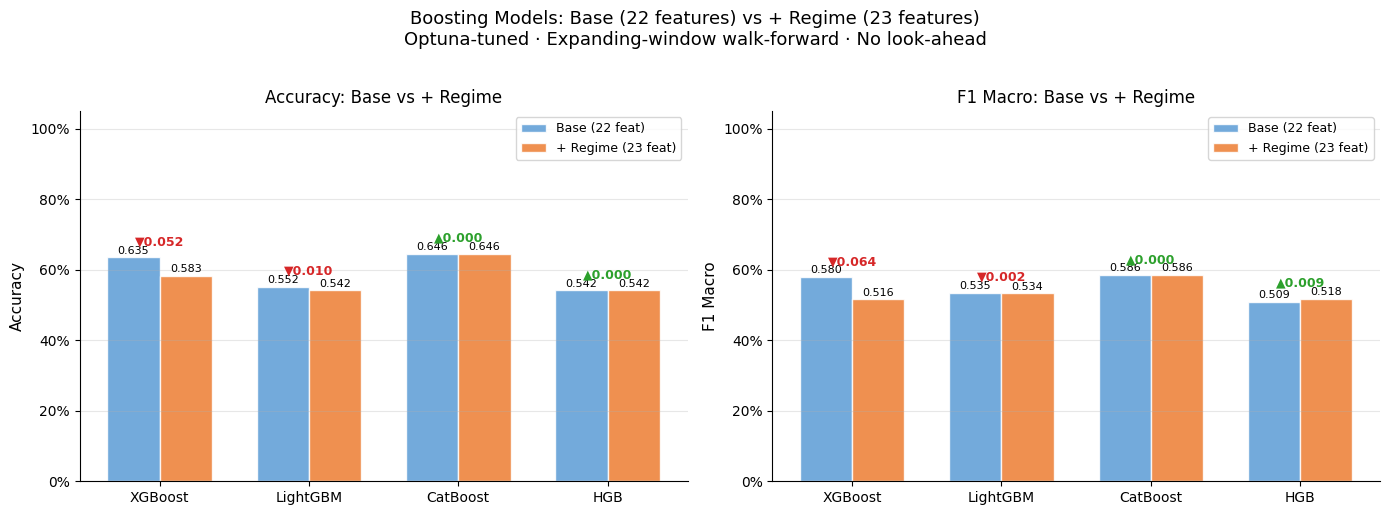

Chart saved to regime_comparison.png

── Summary ──────────────────────────────────────────────────────────────
  XGBoost                ❌ +Regime WORSE   (Δ acc = -0.0521)
  LightGBM               ❌ +Regime WORSE   (Δ acc = -0.0104)
  CatBoost               ➖ +Regime NEUTRAL  (Δ acc = +0.0000)
  HGB                    ➖ +Regime NEUTRAL  (Δ acc = +0.0000)


In [11]:
# ── Visualization: side-by-side accuracy & F1 Macro ───────────────────────────
families = ['XGBoost', 'LightGBM', 'CatBoost', 'HGB']
_rows = [(fam, all_results.get(f'{fam} (base)'), all_results.get(f'{fam} (+ regime)'))
         for fam in families]
_rows = [(f, rb, rr) for f, rb, rr in _rows if rb and rr]

if _rows:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x       = np.arange(len(_rows))
    width   = 0.35
    labels  = [f for f, _, _ in _rows]
    colors  = {'base': '#5B9BD5', 'regime': '#ED7D31'}

    for ax, metric, title in zip(
        axes,
        ['accuracy', 'f1_macro'],
        ['Accuracy', 'F1 Macro'],
    ):
        base_vals   = [rb[metric] for _, rb, _  in _rows]
        regime_vals = [rr[metric] for _, _,  rr in _rows]

        bars_b = ax.bar(x - width/2, base_vals,   width, label='Base (22 feat)',
                         color=colors['base'],   alpha=0.85, edgecolor='white')
        bars_r = ax.bar(x + width/2, regime_vals, width, label='+ Regime (23 feat)',
                         color=colors['regime'], alpha=0.85, edgecolor='white')

        # Annotate bars
        for bar in bars_b:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
        for bar in bars_r:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

        # Delta arrows / labels
        for i, (fam, rb, rr) in enumerate(_rows):
            delta = rr[metric] - rb[metric]
            color = '#2ca02c' if delta >= 0 else '#d62728'
            symbol = '▲' if delta >= 0 else '▼'
            ax.text(i, max(base_vals[i], regime_vals[i]) + 0.025,
                    f'{symbol}{abs(delta):.3f}',
                    ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title}: Base vs + Regime', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        sns.despine(ax=ax)

    fig.suptitle(
        'Boosting Models: Base (22 features) vs + Regime (23 features)\n'
        'Optuna-tuned · Expanding-window walk-forward · No look-ahead',
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.savefig('regime_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved to regime_comparison.png")

# ── Summary verdict ────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────────────────────────")
if rows:
    for row in rows:
        fam   = row['Model']
        delta = row['Δ Acc']
        if delta > 0.005:
            verdict = f"✅ +Regime BETTER  (Δ acc = +{delta:.4f})"
        elif delta < -0.005:
            verdict = f"❌ +Regime WORSE   (Δ acc = {delta:.4f})"
        else:
            verdict = f"➖ +Regime NEUTRAL  (Δ acc = {delta:+.4f})"
        print(f"  {fam:<22s} {verdict}")


---
## 12. Regime-Specific Accuracy Export

This section summarizes accuracy by policy regime using the same walk-forward predictions already computed above.

For each model variant, the notebook:
- aligns each out-of-sample meeting with its pre-meeting realtime regime label
- computes accuracy within each regime bucket
- exports the result to `regime_accuracy_by_model.csv`

The Bayesian update notebook can then use the current regime to up-weight or down-weight the model likelihood.


In [12]:
# ── 12. Regime-specific accuracy export ───────────────────────────────────────
from pathlib import Path

regime_eval = (
    df_regime.loc[INITIAL_TRAIN_SIZE:, ['meeting_date', 'regime_simple']]
    .reset_index(drop=True)
    .copy()
)

regime_accuracy_rows = []
for model_name, result in all_results.items():
    correct = (np.asarray(result['actuals_enc']) == np.asarray(result['preds_enc'])).astype(int)
    if len(correct) != len(regime_eval):
        raise ValueError(
            f'Regime alignment mismatch for {model_name}: '
            f'{len(correct)} predictions vs {len(regime_eval)} regime rows'
        )

    df_eval = regime_eval.copy()
    df_eval['correct'] = correct

    for regime_name, group in df_eval.groupby('regime_simple', dropna=False):
        regime_accuracy_rows.append({
            'model': model_name,
            'regime_simple': regime_name,
            'accuracy': float(group['correct'].mean()),
            'count': int(len(group)),
        })

df_regime_accuracy = (
    pd.DataFrame(regime_accuracy_rows)
    .sort_values(['model', 'regime_simple'])
    .reset_index(drop=True)
)

regime_accuracy_out = Path('regime_accuracy_by_model.csv')
df_regime_accuracy.to_csv(regime_accuracy_out, index=False)

print(f'Regime accuracy table saved to {regime_accuracy_out.resolve()}')
display(df_regime_accuracy)


Regime accuracy table saved to /Users/echohuang/Documents/forecasting_fed_rate/analysis/regime_accuracy_by_model.csv


,model,regime_simple,accuracy,count
0,CatBoost (+ regime),Easing,0.478261,23
1,CatBoost (+ regime),Plateau,0.870968,31
2,CatBoost (+ regime),Tightening,0.571429,42
3,CatBoost (base),Easing,0.478261,23
4,CatBoost (base),Plateau,0.870968,31
5,CatBoost (base),Tightening,0.571429,42
6,HGB (+ regime),Easing,0.434783,23
7,HGB (+ regime),Plateau,0.677419,31
8,HGB (+ regime),Tightening,0.500000,42
9,HGB (base),Easing,0.434783,23
